# Lab Assignment: Data Quality & Data Cleaning for Data Warehouse

**สถานการณ์:** คุณเป็น Data Engineer ของร้านค้าออนไลน์ และได้รับไฟล์ `e_commerce_raw.csv` ที่ต้องเตรียมก่อนโหลดเข้าสู่ Data Warehouse  
**เป้าหมาย:** สำรวจปัญหาคุณภาพข้อมูล ออกแบบกฎการทำความสะอาด และส่งออกข้อมูลที่พร้อมใช้งาน

> ห้ามลบข้อมูลผิดปกติโดยไม่อธิบายเหตุผล ต้องพิจารณา Business Context โดยเฉพาะรายการโปรโมชัน


## ผลลัพธ์การเรียนรู้
1. ตรวจสอบข้อมูลด้วย `info()`, `isnull()`, `describe()` และ `duplicated()`
2. เชื่อมโยงปัญหากับ 6 มิติ: Accuracy, Completeness, Consistency, Uniqueness, Timeliness, Validity
3. จัดการ Missing Values และรูปแบบข้อมูลที่ไม่สอดคล้อง
4. ตรวจจับ Outlier ด้วย IQR และทำ Capping อย่างมีเหตุผล
5. สร้างไฟล์ Clean Data และรายงาน Data Quality ก่อน–หลัง


## 0) เตรียมระบบและอ่านข้อมูล

In [2]:
%matplotlib inline
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_PATH = ROOT / 'e_commerce_raw.csv'
REF_PATH = ROOT / 'customer_reference.csv'
OUTPUT_DIR = ROOT / 'outputs' / 'student_submission'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_columns', 50)
df_raw = pd.read_csv(DATA_PATH)
customer_ref = pd.read_csv(REF_PATH)
df = df_raw.copy()
print('Shape:', df.shape)
print('Customer reference rows:', len(customer_ref))
df.head()

Shape: (630, 16)
Customer reference rows: 167


,Transaction_ID,Customer_ID,Customer_Name,Customer_Email,Gender,Province,Order_Date,Load_Timestamp,Product_Category,Quantity,Unit_Price,Discount_Rate,Transaction_Amount,Payment_Method,Order_Status,Is_Promotion
0,T000127,C0103,Tee Phromla,tee.phromla103@example.com,female,Phuket,2026-06-11,2026-06-11 05:00:00,Sports,3,110.26,0.05,314.24,PP,Cancelled,N
1,T000169,C0138,Mint Dechawat,mint.dechawat138@example.com,M,Khon Kaen,2026-01-24,2026-01-24 01:00:00,Home,3,138.08,0.05,393.53,PromptPay,Processing,N
2,T000003,C0071,Aom Sukjai,aom.sukjai71@example.com,m,Chanthaburi,05/29/2026,2026-05-29 05:00:00,Home,4,263.93,0.00,1055.72,COD,Cancelled,N
3,T000336,C0152,Tee Dechawat,tee.dechawat152@example.com,male,Chanthaburi,02/01/2026,2026-02-01 18:00:00,Food,6,116.53,0.10,629.26,Transfer,Returned,N
4,T000093,C0090,Mook Sukjai,mook.sukjai90@example.com,M,Chanthaburi,2026-04-18,2026-04-18 13:00:00,Electronics,5,358.35,0.00,1791.75,promptpay,Processing,N


## 1) Data Profiling

ให้แสดงผลต่อไปนี้และเขียนข้อสังเกตใต้เซลล์
- โครงสร้างและชนิดข้อมูล
- จำนวน Missing Values รายคอลัมน์
- สถิติเชิงพรรณนาของข้อมูลตัวเลข
- จำนวนแถวซ้ำทั้งแถว
- จำนวนค่าที่แตกต่างในคอลัมน์สำคัญ


In [3]:
# โครงสร้างและชนิดข้อมูล
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630 entries, 0 to 629
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Transaction_ID      630 non-null    object 
 1   Customer_ID         630 non-null    object 
 2   Customer_Name       630 non-null    object 
 3   Customer_Email      580 non-null    object 
 4   Gender              630 non-null    object 
 5   Province            618 non-null    object 
 6   Order_Date          630 non-null    object 
 7   Load_Timestamp      630 non-null    object 
 8   Product_Category    630 non-null    object 
 9   Quantity            630 non-null    int64  
 10  Unit_Price          630 non-null    float64
 11  Discount_Rate       630 non-null    float64
 12  Transaction_Amount  630 non-null    float64
 13  Payment_Method      630 non-null    object 
 14  Order_Status        630 non-null    object 
 15  Is_Promotion        630 non-null    object 
dtypes: float

### คำถาม 1
ระบุปัญหาที่พบอย่างน้อย **5 ปัญหา** และจับคู่กับมิติ Data Quality อย่างน้อย **3 มิติ**

| ปัญหาที่พบ | คอลัมน์ | มิติ Data Quality | หลักฐาน/จำนวนแถว |
|---|---|---|---|
| ค่าว่าง (Missing) | Customer_Email | Completeness | 50 แถว (7.9%) |
| ค่าว่าง (Missing) | Province | Completeness | 12 แถว (1.9%) |
| รูปแบบไม่สอดคล้องกัน (M, m, Male, male, FEMALE, F, f ฯลฯ) | Gender | Consistency | มี 10 ค่าต่างกัน แทนที่จะมีแค่ 2-3 ค่า |
| รูปแบบไม่สอดคล้องกัน (PP, PromptPay, promptpay, CC, Transfer, bank_transfer ฯลฯ) | Payment_Method | Consistency | มี 13 ค่าต่างกัน แทนที่จะมีแค่ 4-5 ค่า |
| รูปแบบวันที่หลายแบบและมีค่าที่ไม่ใช่วันที่ (`not_a_date`) | Order_Date | Consistency / Validity | อย่างน้อย 4 รูปแบบ (`YYYY-MM-DD`, `YYYY/MM/DD`, `DD-MM-YYYY`, `DD/MM/YYYY`) และ 2 แถวอ่านไม่ได้เลย |
| ข้อมูลซ้ำทั้งแถว (Exact Duplicate) | ทุกคอลัมน์ | Uniqueness | 18 แถว |
| ค่านอกกฎธุรกิจ (ต้องอยู่ 1-20) | Quantity | Validity | 3 แถว (พบค่า 0, -3, 99) |
| ยอดไม่ตรงสูตร `Quantity × Unit_Price × (1 − Discount_Rate)` และมีค่าติดลบ/สูงผิดปกติ | Transaction_Amount | Accuracy | 51 แถวต่างจากสูตรเกิน 1 บาท, พบค่าติดลบ (-500, -1) และค่าผิดปกติสูงมาก (666666-999999) |

**สรุปมิติที่พบปัญหา:** Completeness, Consistency, Uniqueness, Validity, Accuracy (ครบทั้ง 5 จาก 6 มิติ ยกเว้น Timeliness ที่จะตรวจใน Task 7)

## 2) Completeness: จัดการ Missing Values

In [4]:
# TODO 2.1: ตรวจสอบ Customer_Email และ Province ที่หายไป
print('Customer_Email missing:', df['Customer_Email'].isna().sum())
print('Province missing:', df['Province'].isna().sum())

# TODO 2.2/2.3: สร้าง flag ก่อนแก้ไข (ก่อนใช้ข้อมูลอ้างอิงหรือ placeholder ใด ๆ)
df['Customer_Email_Was_Missing'] = df['Customer_Email'].isna()
df['Province_Was_Missing'] = df['Province'].isna()

# มี customer_reference.csv เป็นตาราง Master Data (Customer_ID -> Email, Province ที่ถูกต้อง)
# จึงควรใช้เติมค่าที่ถูกต้องจากแหล่งอ้างอิงนี้ก่อน แทนที่จะเดา/สร้างค่าสมมติทันที
ref_email = customer_ref.set_index('Customer_ID')['Customer_Email']
ref_province = customer_ref.set_index('Customer_ID')['Province']

df['Customer_Email'] = df['Customer_Email'].fillna(df['Customer_ID'].map(ref_email))
df['Province'] = df['Province'].fillna(df['Customer_ID'].map(ref_province))

# ห้าม dropna() เพราะจะทำให้ Fact rows และยอดขายที่แถวนั้นถืออยู่หายไปจาก Warehouse ทั้งที่ธุรกรรมเกิดขึ้นจริง
# ถ้า Customer_ID ไม่มีอยู่ใน Master Data เลย (หา Email จริงไม่ได้) จึงค่อย fallback เป็น placeholder ที่ traceable
still_missing_email = df['Customer_Email'].isna()
df.loc[still_missing_email, 'Customer_Email'] = (
    'unknown_' + df.loc[still_missing_email, 'Customer_ID'] + '@unknown.local'
)
df['Province'] = df['Province'].fillna('Unknown')

print('\nเติมจาก customer_reference.csv:')
print('  Email เติมจากอ้างอิงได้:', (df['Customer_Email_Was_Missing'] & ~still_missing_email).sum())
print('  Email ต้องใช้ placeholder (ไม่พบใน reference):', still_missing_email.sum())
print('\nหลังแก้ไขทั้งหมด:')
print('Customer_Email_Was_Missing:', df['Customer_Email_Was_Missing'].sum())
print('Province_Was_Missing:', df['Province_Was_Missing'].sum())
print('Customer_Email เหลือ Null:', df['Customer_Email'].isna().sum())

Customer_Email missing: 50
Province missing: 12

เติมจาก customer_reference.csv:
  Email เติมจากอ้างอิงได้: 47
  Email ต้องใช้ placeholder (ไม่พบใน reference): 3

หลังแก้ไขทั้งหมด:
Customer_Email_Was_Missing: 50
Province_Was_Missing: 12
Customer_Email เหลือ Null: 0


### คำถาม 2
อธิบายว่าเหตุใดการใช้ `dropna()` กับ `Customer_Email` อาจทำให้ยอดขายรวมใน Data Warehouse ผิดเพี้ยน และเหตุใดการเติมค่าเฉลี่ยจึงไม่เหมาะกับข้อมูลประเภทอีเมล

**คำตอบ:** `Customer_Email` ที่หายไปเป็นเพียง Attribute ของลูกค้า ไม่ใช่ปัญหาที่ตัว Fact (ธุรกรรมการขาย) เอง หากใช้ `dropna()` จะทำให้ทั้งแถว — รวมถึง `Transaction_Amount` ที่แถวนั้นถืออยู่ — ถูกลบไปด้วย ทำให้ยอดขายรวมใน `fact_sales` ต่ำกว่าความเป็นจริง (Undercount) ทั้งที่ธุรกรรมนั้นเกิดขึ้นจริงและควรถูกนับ

ส่วน Mean Imputation ใช้ไม่ได้กับอีเมลเพราะอีเมลเป็นข้อมูลประเภทข้อความที่ต้องไม่ซ้ำกัน (Unique/Identifier) ไม่ใช่ตัวเลขเชิงปริมาณที่มีค่าเฉลี่ยตามธรรมชาติ การเติมค่าเฉลี่ยไม่มีความหมายทางคณิตศาสตร์ และถ้าเติมด้วยค่าคงที่ค่าเดียวกันทุกแถว จะทำให้ลูกค้าหลายคนถูกยุบรวมเป็นคนเดียวกันอย่างผิดพลาด (สร้าง False Uniqueness/Duplicate ทางอ้อม)

ในทางปฏิบัติ Lab นี้มี `customer_reference.csv` เป็น Master Data ของลูกค้าอยู่แล้ว จึงเติมอีเมล/จังหวัดจริงจากตารางนี้ผ่าน `Customer_ID` ก่อนเป็นลำดับแรก (แก้ปัญหาได้ 47 จาก 50 แถว) แล้วจึงค่อย fallback เป็น Placeholder แบบ Traceable (`unknown_<Customer_ID>@unknown.local`) เฉพาะกรณีที่หา `Customer_ID` ไม่พบใน Master Data เลย (3 แถวที่เหลือ)

## 3) Consistency: จัดรูปแบบข้อมูลให้เป็นมาตรฐาน

In [5]:
# TODO 3.1: Standardize Gender ให้เหลือ M, F, Unknown
def clean_gender(g):
    g = str(g).strip().lower()
    if g in ('m', 'male'):
        return 'M'
    if g in ('f', 'female'):
        return 'F'
    return 'Unknown'

df['Gender'] = df['Gender'].apply(clean_gender)

# TODO 3.2: Standardize Payment_Method
payment_map = {
    'pp': 'PromptPay', 'promptpay': 'PromptPay', 'prompt pay': 'PromptPay',
    'cod': 'Cash on Delivery', 'cash on delivery': 'Cash on Delivery', 'cash': 'Cash on Delivery',
    'transfer': 'Bank Transfer', 'bank_transfer': 'Bank Transfer', 'bank transfer': 'Bank Transfer',
    'cc': 'Credit Card', 'credit card': 'Credit Card', 'card': 'Credit Card',
}

def clean_payment(p):
    return payment_map.get(str(p).strip().lower(), 'Unknown')

df['Payment_Method'] = df['Payment_Method'].apply(clean_payment)

print(df['Gender'].value_counts())
print()
print(df['Payment_Method'].value_counts())

# TODO 3.3: แปลง Order_Date หลายรูปแบบให้เป็น YYYY-MM-DD
# ใช้ Load_Timestamp ช่วยตัดสินกรณีวันที่กำกวมระหว่าง DD/MM/YYYY และ MM/DD/YYYY
load_dt = pd.to_datetime(df['Load_Timestamp'])


def parse_order_date(raw, load_ts):
    s = str(raw).strip()
    # กรณี ISO: YYYY-MM-DD หรือ YYYY/MM/DD (ปีอยู่หน้า ไม่กำกวม)
    for sep in ('-', '/'):
        parts = s.split(sep)
        if len(parts) == 3 and len(parts[0]) == 4:
            try:
                return pd.Timestamp(year=int(parts[0]), month=int(parts[1]), day=int(parts[2])), 'ISO'
            except (ValueError, TypeError):
                pass
    # กรณีปีอยู่ท้าย: DD-MM-YYYY / DD/MM/YYYY / MM-DD-YYYY / MM/DD/YYYY
    for sep in ('-', '/'):
        parts = s.split(sep)
        if len(parts) == 3 and len(parts[2]) == 4:
            try:
                a, b, year = int(parts[0]), int(parts[1]), int(parts[2])
            except ValueError:
                continue
            candidates = []
            if a <= 31 and b <= 12:
                try:
                    candidates.append((pd.Timestamp(year=year, month=b, day=a), 'DMY'))
                except ValueError:
                    pass
            if b <= 31 and a <= 12 and a != b:
                try:
                    candidates.append((pd.Timestamp(year=year, month=a, day=b), 'MDY'))
                except ValueError:
                    pass
            if not candidates:
                continue
            if len(candidates) == 1:
                return candidates[0]
            # กำกวม (ตีความได้ทั้งสองแบบ): เลือกแบบที่ Order_Date ไม่เกิน Load_Timestamp
            # และใกล้เวลาที่โหลดเข้าระบบที่สุด (สมเหตุสมผลที่สุดทางธุรกิจ)
            valid = [c for c in candidates if c[0].normalize() <= load_ts.normalize()]
            pool = valid if valid else candidates
            best = min(pool, key=lambda c: abs((load_ts.normalize() - c[0].normalize()).days))
            return best[0], best[1] + '_disambiguated'
    return pd.NaT, 'unparseable'


parsed = [parse_order_date(raw, load_dt.iloc[i]) for i, raw in enumerate(df['Order_Date'])]
df['Order_Date_Parsed'] = [p[0] for p in parsed]
df['Order_Date_Parse_Method'] = [p[1] for p in parsed]

# ค่าที่อ่านไม่ได้เลย -> fallback เป็นวันที่จาก Load_Timestamp พร้อม flag ว่าเป็นค่ากะประมาณ
df['Order_Date_Was_Imputed'] = df['Order_Date_Parsed'].isna()
df.loc[df['Order_Date_Was_Imputed'], 'Order_Date_Parsed'] = load_dt[df['Order_Date_Was_Imputed']].dt.normalize()
df.loc[df['Order_Date_Was_Imputed'], 'Order_Date_Parse_Method'] = 'load_timestamp_fallback'

df['Order_Date'] = df['Order_Date_Parsed'].dt.strftime('%Y-%m-%d')
df = df.drop(columns=['Order_Date_Parsed'])

print()
print(df['Order_Date_Parse_Method'].value_counts())
print('Order_Date_Was_Imputed:', df['Order_Date_Was_Imputed'].sum())

Gender
M    344
F    286
Name: count, dtype: int64

Payment_Method
PromptPay           173
Bank Transfer       163
Credit Card         159
Cash on Delivery    135
Name: count, dtype: int64

Order_Date_Parse_Method
ISO                        409
DMY                         87
MDY                         49
DMY_disambiguated           42
MDY_disambiguated           36
load_timestamp_fallback      7
Name: count, dtype: int64
Order_Date_Was_Imputed: 7


### คำถาม 3
ยกตัวอย่าง 1 วันที่สามารถตีความได้ทั้ง DD/MM/YYYY และ MM/DD/YYYY แล้วอธิบายว่าคุณใช้หลักฐานใดช่วยตัดสิน

**คำตอบ:** ตัวอย่างเช่นค่าดิบ `02/01/2026` ตีความได้ 2 แบบ คือ 2 มกราคม 2026 (DD/MM/YYYY) หรือ 1 กุมภาพันธ์ 2026 (MM/DD/YYYY) — ทั้งสองแบบเป็นวันที่ที่ถูกต้องตามปฏิทิน จึงกำกวมด้วยตัวมันเอง

หลักฐานที่ใช้ตัดสินคือ **`Load_Timestamp`** (เวลาที่ข้อมูลเข้าสู่ระบบ) เพราะตามธุรกิจจริงแล้ว `Order_Date` ต้องเกิดขึ้น "ก่อนหรือพร้อมกับ" `Load_Timestamp` เสมอ (สั่งซื้อก่อน ข้อมูลถึงจะเข้าคลัง) ดังนั้นถ้าตีความแบบหนึ่งทำให้วันที่สั่งซื้ออยู่หลังวันที่โหลดเข้าระบบ (เป็นไปไม่ได้ทางธุรกิจ) จะตัดตัวเลือกนั้นทิ้ง และถ้ายังกำกวมอยู่ (ทั้งสองแบบเกิดก่อน Load_Timestamp ได้) จะเลือกแบบที่ระยะห่างจาก `Load_Timestamp` น้อยที่สุด เพราะสอดคล้องกับพฤติกรรมการโหลดข้อมูลที่มักทำใกล้เคียงกับวันที่สั่งซื้อมากกว่า

## 4) Uniqueness: ข้อมูลซ้ำและความซ้ำซ้อนเชิงความหมาย

In [6]:
# TODO 4.1: นับและลบ Exact Duplicate โดยเก็บแถวแรก
before_rows = len(df)
exact_dupes = df.duplicated().sum()
df = df.drop_duplicates(keep='first').reset_index(drop=True)
print(f'Exact duplicates removed: {exact_dupes} (rows: {before_rows} -> {len(df)})')

# TODO 4.2 (Bonus): ตรวจหาลูกค้าที่ Customer_ID/Customer_Email เดียวกัน แต่ Customer_Name เขียนต่างกัน
near_dupe_ids = df.groupby('Customer_ID')['Customer_Name'].nunique()
near_dupe_ids = near_dupe_ids[near_dupe_ids > 1]
print('\nCustomer_ID ที่มี Customer_Name เขียนต่างกัน:', len(near_dupe_ids))
df[df['Customer_ID'].isin(near_dupe_ids.index)][['Customer_ID', 'Customer_Name', 'Customer_Email']].drop_duplicates()

Exact duplicates removed: 18 (rows: 630 -> 612)

Customer_ID ที่มี Customer_Name เขียนต่างกัน: 1


,Customer_ID,Customer_Name,Customer_Email
95,C0047,Ploy Saelim,ploy.saelim47@example.com
96,C0047,Ploy Saelim,ploy.saelim47@example.com


## 5) Accuracy และ Validity: ตรวจสอบกฎธุรกิจ

In [7]:
# TODO 5.1: แปลง Quantity, Unit_Price, Discount_Rate และ Transaction_Amount เป็นตัวเลข
for col in ['Quantity', 'Unit_Price', 'Discount_Rate', 'Transaction_Amount']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# TODO 5.2: ตรวจ Quantity ต้องอยู่ในช่วง 1-20
df['Quantity_Was_Invalid'] = ~df['Quantity'].between(1, 20)
print('Quantity นอกช่วง 1-20:', df['Quantity_Was_Invalid'].sum())

# TODO 5.3: คำนวณ Expected_Amount และสร้าง Accuracy_Flag เมื่อผลต่างเกิน 1 บาท
df['Expected_Amount'] = (df['Quantity'] * df['Unit_Price'] * (1 - df['Discount_Rate'])).round(2)
df['Accuracy_Flag'] = (df['Transaction_Amount'] - df['Expected_Amount']).abs() > 1
print('ยอดไม่ตรงสูตร (เกิน 1 บาท):', df['Accuracy_Flag'].sum())
print('  - ในจำนวนนี้เป็นรายการโปรโมชัน (Is_Promotion = Y):', (df['Accuracy_Flag'] & (df['Is_Promotion'] == 'Y')).sum())
print('  - ที่ไม่ใช่โปรโมชัน (Is_Promotion = N):', (df['Accuracy_Flag'] & (df['Is_Promotion'] == 'N')).sum())

# TODO 5.4: Standardize Order_Status และตรวจค่าที่ไม่อยู่ในชุดที่กำหนด
status_map = {
    'completed': 'Completed', 'done': 'Completed',
    'processing': 'Processing',
    'cancelled': 'Cancelled', 'cancel': 'Cancelled',
    'returned': 'Returned',
}

def clean_status(s):
    return status_map.get(str(s).strip().lower(), 'Unknown')

df['Order_Status'] = df['Order_Status'].apply(clean_status)
print()
print(df['Order_Status'].value_counts())

# ไม่แก้ยอดของรายการโปรโมชันอัตโนมัติ -- เก็บไว้ตรวจสอบด้วย Business Context ตามข้อกำหนดสำคัญของ Lab

Quantity นอกช่วง 1-20: 3
ยอดไม่ตรงสูตร (เกิน 1 บาท): 50
  - ในจำนวนนี้เป็นรายการโปรโมชัน (Is_Promotion = Y): 7
  - ที่ไม่ใช่โปรโมชัน (Is_Promotion = N): 43

Order_Status
Completed     164
Processing    159
Cancelled     151
Returned      133
Unknown         5
Name: count, dtype: int64


### คำถาม 4
รายการที่ `Transaction_Amount` ไม่ตรงกับสูตรควรถูกแก้ไขทุกแถวหรือไม่? ให้อธิบายผลของ `Is_Promotion` ต่อการตัดสินใจ

**คำตอบ:** ไม่ควรแก้ไขทุกแถวโดยอัตโนมัติ ต้องแยกพิจารณาตาม `Is_Promotion` ก่อน:

- รายการที่ `Is_Promotion = 'N'` (ไม่ใช่โปรโมชัน) แล้วยอดไม่ตรงสูตร มีแนวโน้มสูงว่าเป็น **ข้อผิดพลาดจากการบันทึกข้อมูลจริง** (เช่นค่าที่เห็นในข้อมูลนี้ 666666-999999 บาท หรือค่าติดลบ) สามารถพิจารณาแก้ไข/Cap ค่าได้อย่างมั่นใจกว่า
- รายการที่ `Is_Promotion = 'Y'` แล้วยอดไม่ตรงสูตรพื้นฐาน `Quantity × Unit_Price × (1 − Discount_Rate)` **อาจไม่ใช่ข้อผิดพลาด** เพราะโปรโมชันมักมีเงื่อนไขทางธุรกิจเพิ่มเติมที่สูตรนี้ไม่ได้ครอบคลุม เช่น คูปองส่วนลดเพิ่ม, ราคาพิเศษเฉพาะแคมเปญ หรือส่วนลดแบบขั้นบันได การแก้ยอดเหล่านี้อัตโนมัติโดยไม่ตรวจสอบ Business Context อาจทำให้ข้อมูลที่ถูกต้องอยู่แล้วถูกเปลี่ยนเป็นค่าที่ผิด

ดังนั้นค่า `Accuracy_Flag` จึงถูกสร้างไว้ให้ทีมธุรกิจตรวจสอบเพิ่มเติม ไม่ใช่แก้ไขอัตโนมัติทันที

## 6) Outliers: IQR และ Capping/Clipping

Q1=310.80  Q3=1023.48  IQR=712.68  Lower=-758.22  Upper=2092.50
Outliers พบ (เฉพาะรายการที่ไม่ใช่โปรโมชัน): 19


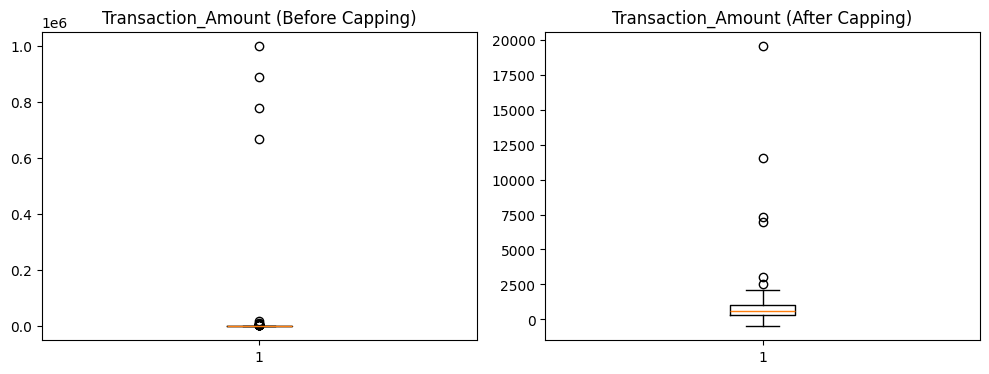

In [8]:
# TODO 6.1: ใช้เฉพาะรายการที่ Is_Promotion != 'Y' คำนวณ Q1, Q3, IQR, Lower Bound, Upper Bound
non_promo_amount = df.loc[df['Is_Promotion'] != 'Y', 'Transaction_Amount']
Q1 = non_promo_amount.quantile(0.25)
Q3 = non_promo_amount.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
print(f'Q1={Q1:.2f}  Q3={Q3:.2f}  IQR={IQR:.2f}  Lower={lower:.2f}  Upper={upper:.2f}')

# TODO 6.2: สร้าง Outlier Flag ก่อนทำ Capping (เฉพาะรายการที่ไม่ใช่โปรโมชัน)
non_promo_mask = df['Is_Promotion'] != 'Y'
df['Outlier_Flag_Before_Capping'] = non_promo_mask & (
    (df['Transaction_Amount'] < lower) | (df['Transaction_Amount'] > upper)
)
print('Outliers พบ (เฉพาะรายการที่ไม่ใช่โปรโมชัน):', df['Outlier_Flag_Before_Capping'].sum())

# TODO 6.3: ใช้ .clip() กับ Transaction_Amount เฉพาะรายการที่ไม่ใช่โปรโมชัน
before_capping = df['Transaction_Amount'].copy()
df.loc[non_promo_mask, 'Transaction_Amount'] = df.loc[non_promo_mask, 'Transaction_Amount'].clip(lower=lower, upper=upper)

# TODO 6.4: แสดง Boxplot ก่อนและหลัง Capping
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].boxplot(before_capping.dropna())
axes[0].set_title('Transaction_Amount (Before Capping)')
axes[1].boxplot(df['Transaction_Amount'].dropna())
axes[1].set_title('Transaction_Amount (After Capping)')
plt.tight_layout()
plt.show()

### คำถาม 5
เพราะเหตุใดข้อมูลที่อยู่นอก IQR Bound จึงไม่จำเป็นต้องเป็นข้อมูลผิดเสมอ? ยกตัวอย่างจาก Dataset นี้

**คำตอบ:** ขอบเขต IQR เป็นการประมาณค่าทางสถิติจากการกระจายตัวของข้อมูล "ส่วนใหญ่" เท่านั้น ไม่ได้รู้ถึงเหตุผลทางธุรกิจเบื้องหลังตัวเลข ค่าที่หลุดขอบเขตอาจเป็นธุรกรรมจริงที่มีมูลค่าสูง/ต่ำผิดปกติด้วยเหตุผลที่ถูกต้อง เช่น ลูกค้าซื้อจำนวนมากเป็นพิเศษ หรือเป็นรายการโปรโมชันที่ตั้งใจตั้งราคาต่างจากปกติ

ใน Dataset นี้เห็นได้ชัดจากรายการที่ `Is_Promotion = 'Y'` เช่นยอด 19,610.76 หรือ 11,530.53 บาท ซึ่งสูงกว่ายอดขายทั่วไปมาก แต่เป็นรายการโปรโมชันที่ตั้งใจให้มีมูลค่าสูง (เช่นแคมเปญซื้อคุ้ม/ชุดสินค้าราคาพิเศษ) จึงไม่ควรถูกจัดเป็น "ข้อมูลผิด" และไม่ถูกนำมาคำนวณ IQR หรือ Capping เลยตามข้อกำหนดของ Lab ต่างจากค่าอย่าง 999,999 หรือ -500 บาทในรายการที่ไม่ใช่โปรโมชัน ซึ่งสมเหตุสมผลกว่าที่จะเป็นข้อผิดพลาดจากการบันทึกข้อมูล

## 7) Timeliness: ความทันเวลาในการโหลดข้อมูล

In [9]:
# TODO 7: คำนวณ Load_Delay_Hours จาก Order_Date ถึง Load_Timestamp
order_dt_clean = pd.to_datetime(df['Order_Date'])
load_dt_clean = pd.to_datetime(df['Load_Timestamp'])

df['Load_Delay_Hours'] = (load_dt_clean - order_dt_clean).dt.total_seconds() / 3600
df['Late'] = df['Load_Delay_Hours'] > 24

late_count = df['Late'].sum()
late_pct = df['Late'].mean() * 100
print(f'Late loads (> 24 ชั่วโมง): {late_count} แถว ({late_pct:.1f}%)')
df[['Order_Date', 'Load_Timestamp', 'Load_Delay_Hours', 'Late']].head()

Late loads (> 24 ชั่วโมง): 38 แถว (6.2%)


,Order_Date,Load_Timestamp,Load_Delay_Hours,Late
0,2026-06-11,2026-06-11 05:00:00,5.0,False
1,2026-01-24,2026-01-24 01:00:00,1.0,False
2,2026-05-29,2026-05-29 05:00:00,5.0,False
3,2026-02-01,2026-02-01 18:00:00,18.0,False
4,2026-04-18,2026-04-18 13:00:00,13.0,False


## 8) Data Quality Report และ Export

In [10]:
# TODO 8.1: สรุปตัวชี้วัดก่อนและหลัง Cleaning เป็น DataFrame
raw_expected = df_raw['Quantity'] * df_raw['Unit_Price'] * (1 - df_raw['Discount_Rate'])
raw_mismatch = (df_raw['Transaction_Amount'] - raw_expected).abs() > 1
raw_invalid_status = ~df_raw['Order_Status'].astype(str).str.strip().str.lower().isin(
    ['completed', 'done', 'processing', 'cancelled', 'cancel', 'returned']
)

report = pd.DataFrame([
    {'metric': 'Total rows', 'before': len(df_raw), 'after': len(df)},
    {'metric': 'Exact duplicate rows', 'before': int(df_raw.duplicated().sum()), 'after': int(df.duplicated().sum())},
    {'metric': 'Missing Customer_Email', 'before': int(df_raw['Customer_Email'].isna().sum()), 'after': int(df['Customer_Email'].isna().sum())},
    {'metric': 'Missing Province', 'before': int(df_raw['Province'].isna().sum()), 'after': int(df['Province'].isna().sum())},
    {'metric': 'Invalid/imputed Order_Date', 'before': int((df_raw['Order_Date'] == 'not_a_date').sum()), 'after': int(df['Order_Date_Was_Imputed'].sum())},
    {'metric': 'Quantity out of business range (1-20)', 'before': int(((pd.to_numeric(df_raw['Quantity'], errors='coerce') < 1) | (pd.to_numeric(df_raw['Quantity'], errors='coerce') > 20)).sum()), 'after': int(df['Quantity_Was_Invalid'].sum())},
    {'metric': 'Transaction_Amount mismatched formula (>1 baht)', 'before': int(raw_mismatch.sum()), 'after': int(df['Accuracy_Flag'].sum())},
    {'metric': 'Outliers capped (non-promo, IQR)', 'before': int(df['Outlier_Flag_Before_Capping'].sum()), 'after': 0},
    {'metric': 'Late loads (>24h)', 'before': int(df['Late'].sum()), 'after': int(df['Late'].sum())},
    {'metric': 'Invalid Order_Status', 'before': int(raw_invalid_status.sum()), 'after': int((df['Order_Status'] == 'Unknown').sum())},
])
display(report)

# TODO 8.2: Export
df.to_csv(OUTPUT_DIR / 'e_commerce_clean.csv', index=False, encoding='utf-8-sig')
report.to_csv(OUTPUT_DIR / 'data_quality_report.csv', index=False, encoding='utf-8-sig')
print('Exported to', OUTPUT_DIR)

,metric,before,after
0,Total rows,630,612
1,Exact duplicate rows,18,0
2,Missing Customer_Email,50,0
3,Missing Province,12,0
4,Invalid/imputed Order_Date,2,7
5,Quantity out of business range (1-20),3,3
6,Transaction_Amount mismatched formula (>1 baht),51,50
7,"Outliers capped (non-promo, IQR)",19,0
8,Late loads (>24h),38,38
9,Invalid Order_Status,5,5


Exported to /Users/surachat/Desktop/67160378/BUU/ไฟล์ปี3/LAB-Data Warehousing Concepts and Design/Week05/outputs/student_submission


## 9) Reflection
ตอบเป็นย่อหน้าสั้น ๆ

**1. ขั้นตอนใดมีความเสี่ยงทำให้ข้อมูลจริงสูญหายมากที่สุด?**
ขั้นตอน Capping/Clipping ค่า Outlier ใน Task 6 มีความเสี่ยงสูงสุด เพราะเป็นการเปลี่ยนแปลงตัวเลขจริงของธุรกรรม (ไม่ใช่แค่ปรับรูปแบบข้อความเหมือน Task 3) หากตั้งเงื่อนไขผิดพลาด (เช่นลืมกรอง `Is_Promotion` ออกก่อนคำนวณ IQR) จะทำให้ยอดขายจริงที่มีมูลค่าสูงจากโปรโมชันถูกบีบให้ต่ำลงอย่างผิดพลาด ส่งผลต่อความถูกต้องของยอดขายรวมโดยตรง

**2. กฎใดควรนำไปทำ Automation ใน Data Pipeline?**
กฎที่ตรวจสอบได้อย่างชัดเจนไม่มีความกำกวม เช่น การมาตรฐานรูปแบบ Gender/Payment_Method/Order_Status (Task 3, 5) และการตรวจ Exact Duplicate (Task 4) ควรทำเป็น Automation ได้เต็มรูปแบบ เพราะเป็นกฎตายตัวไม่ต้องใช้วิจารณญาณทางธุรกิจ ส่วนการตัดสินใจแก้ไขยอดที่ไม่ตรงสูตรของรายการโปรโมชัน (Task 5) ไม่ควร Automate เต็มรูปแบบ ควรมีขั้นตอนตรวจสอบโดยคนหรือกฎที่ซับซ้อนกว่านี้

**3. หากใช้ Great Expectations คุณจะสร้าง Expectation ใดอย่างน้อย 3 ข้อ?**
- `expect_column_values_to_not_be_null` บนคอลัมน์ `Transaction_ID` และ `Customer_ID` (ต้องไม่มีค่าว่างในคีย์หลัก)
- `expect_column_values_to_be_between` บนคอลัมน์ `Quantity` ให้อยู่ในช่วง 1-20 ตามกฎธุรกิจ
- `expect_column_values_to_be_in_set` บนคอลัมน์ `Gender`, `Payment_Method`, `Order_Status` ให้อยู่ในชุดค่าที่มาตรฐานแล้วเท่านั้น
- `expect_column_pair_values_A_to_be_greater_than_B` เปรียบเทียบ `Load_Timestamp` ต้องมากกว่าหรือเท่ากับ `Order_Date` เสมอ

## Checklist ก่อนส่ง
- [x] Notebook รันจากบนลงล่างได้โดยไม่ Error
- [x] มีคำตอบคำถามทั้ง 5 ข้อและ Reflection
- [x] ส่ง `e_commerce_clean.csv`
- [x] ส่ง `data_quality_report.csv`
- [x] ไม่ลบรายการโปรโมชันเพียงเพราะเป็น Outlier